# Step 4.1 — In Silico Proteolysis

**Purpose:** Predict protease cleavage sites on the three Durrani et al. source peptides, then
cross-reference those sites against per-residue SASA from Phase 3 MD to identify cleavage events
that DES solvents are predicted to enhance.

**Inputs:**
- Durrani et al. source peptide sequences (GGE: Peptide 6, CME: Peptide 5, YIY: Peptide 83)
- Phase 3 per-system MD metrics (`analysis/per_system_metrics.csv`)
- Phase 3 comparative deltas (`analysis/comparative_deltas.csv`)

**Outputs:**
- `downstream/proteolysis/cleavage_sites.csv` — all predicted cleavage sites per peptide × protease
- `downstream/proteolysis/cleavage_fragments.csv` — all predicted fragments with motif annotations
- `downstream/proteolysis/cleavage_sasa_overlay.csv` — cleavage sites with SASA from each solvent condition
- `downstream/proteolysis/figures/` — cleavage map visualisations

**Approach:**
1. Implement protease specificity rules for trypsin, pepsin, and chymotrypsin
2. Predict cleavage positions on each source peptide
3. Generate all resulting fragments, annotating which contain the bioactive motif
4. Map cleavage-site residues onto the capped construct coordinate frame
5. Overlay per-residue SASA from Phase 3 (water vs reline vs glyceline)
6. Identify cleavage sites where ΔSASA > 0 in DES — these are predicted to be more efficiently cleaved

**Key constraint:** The MD constructs are capped sub-sequences of the Durrani peptides.
Only residues present in both the source peptide AND the MD construct can be directly
mapped to SASA values. Cleavage sites outside the construct window are noted but lack
MD-derived accessibility data.

**Runtime estimate:** < 1 minute (pure Python, no trajectory I/O)

## 1. Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# --- Output directories ---
OUT_DIR = Path("downstream/proteolysis")
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Peptide definitions ---
# Source peptides from Durrani et al. (full LC-MS/MS identified sequences)
# Construct sequences are the capped sub-sequences used in MD
PEPTIDES = {
    'GGE': {
        'source_name': 'Peptide 6',
        'source_seq': 'NTDEEEGGEIVFGGVDPK',
        'construct_seq': 'EEEGGEIVF',          # Ace-EEEGGEIVF-NMe
        'motif': 'GGE',
        'motif_pos_source': (6, 7, 8),          # 0-indexed in source
        'motif_pos_construct': (3, 4, 5),        # 0-indexed in construct
        'construct_offset': 3,                   # source index = construct index + offset
    },
    'CME': {
        'source_name': 'Peptide 5',
        'source_seq': 'LYQCMEFVR',
        'construct_seq': 'LYQCMEFVR',           # Ace-LYQCMEFVR-NMe (identical)
        'motif': 'CME',
        'motif_pos_source': (3, 4, 5),
        'motif_pos_construct': (3, 4, 5),
        'construct_offset': 0,
    },
    'YIY': {
        'source_name': 'Peptide 83',
        'source_seq': 'NPYIYK',
        'construct_seq': 'NPYIYK',              # Ace-NPYIYK-NMe (identical)
        'motif': 'YIY',
        'motif_pos_source': (2, 3, 4),
        'motif_pos_construct': (2, 3, 4),
        'construct_offset': 0,
    },
}

SOLVENTS = ['water', 'reline', 'glyceline']

print("Peptide definitions loaded:")
for name, info in PEPTIDES.items():
    src = info['source_seq']
    con = info['construct_seq']
    print(f"  {name}: source={src} ({len(src)} aa), "
          f"construct={con} ({len(con)} aa), offset={info['construct_offset']}")

Peptide definitions loaded:
  GGE: source=NTDEEEGGEIVFGGVDPK (18 aa), construct=EEEGGEIVF (9 aa), offset=3
  CME: source=LYQCMEFVR (9 aa), construct=LYQCMEFVR (9 aa), offset=0
  YIY: source=NPYIYK (6 aa), construct=NPYIYK (6 aa), offset=0


## 2. Protease specificity rules

Implemented from established biochemical specificity:
- **Trypsin:** Cleaves C-terminal to K and R, except when followed by P
- **Chymotrypsin:** Cleaves C-terminal to F, W, Y, and (with lower efficiency) L, M, H — except when followed by P
- **Pepsin (pH 2.0):** Cleaves at hydrophobic residues (F, L, W, Y, A, E) on either side of the scissile bond; modelled as cleavage C-terminal to F, L, W, Y and N-terminal to F, L, W, Y

Pepsin has broader and less deterministic specificity than trypsin/chymotrypsin.
The rules below follow the ExPASy PeptideCutter implementation for consistency
with the workflow document.

In [2]:
def predict_trypsin(sequence):
    """Predict trypsin cleavage sites.
    
    Cleaves C-terminal to K or R, unless followed by P.
    Returns list of (position, rule) where position is the 0-indexed
    residue AFTER which cleavage occurs (i.e., the P1 residue).
    """
    sites = []
    for i, aa in enumerate(sequence):
        if aa in ('K', 'R'):
            # Check not followed by P (unless last residue)
            if i == len(sequence) - 1:
                continue  # C-terminal residue — no cleavage after terminus
            if sequence[i + 1] != 'P':
                sites.append((i, f'Trypsin: C-term to {aa}{i+1}'))
    return sites


def predict_chymotrypsin(sequence):
    """Predict chymotrypsin cleavage sites.
    
    High specificity: F, W, Y
    Lower specificity: L, M, H
    No cleavage if followed by P.
    """
    high_spec = set('FWY')
    low_spec = set('LMH')
    sites = []
    for i, aa in enumerate(sequence):
        if aa in high_spec or aa in low_spec:
            if i == len(sequence) - 1:
                continue
            if sequence[i + 1] != 'P':
                spec = 'high' if aa in high_spec else 'low'
                sites.append((i, f'Chymotrypsin ({spec}): C-term to {aa}{i+1}'))
    return sites


def predict_pepsin_ph2(sequence):
    """Predict pepsin (pH 2.0) cleavage sites.
    
    Pepsin at pH 2.0 preferentially cleaves at hydrophobic residues.
    ExPASy PeptideCutter rules (pH > 2):
    - Cleaves C-terminal to F, L in most contexts
    - Does NOT cleave if P1 is preceded by H, K, R (for F) or
      if followed by certain residues in specific contexts
    
    Simplified implementation: cleaves C-terminal to F, L, W, Y, E
    with exceptions for specific flanking residues.
    This follows the commonly used broad pepsin model.
    """
    # Pepsin preferred P1 residues at pH ~2
    p1_residues = set('FLWY')
    # Also cleaves N-terminal to these (P1' position)
    p1_prime = set('FLWY')
    
    sites = []
    seen = set()
    
    # C-terminal cleavage (after P1)
    for i, aa in enumerate(sequence):
        if aa in p1_residues and i < len(sequence) - 1:
            key = i
            if key not in seen:
                sites.append((i, f'Pepsin: C-term to {aa}{i+1}'))
                seen.add(key)
    
    # N-terminal cleavage (before P1') — equivalent to cleavage after i-1
    for i, aa in enumerate(sequence):
        if aa in p1_prime and i > 0:
            key = i - 1
            if key not in seen:
                sites.append((i - 1, f'Pepsin: N-term to {aa}{i+1}'))
                seen.add(key)
    
    sites.sort(key=lambda x: x[0])
    return sites


PROTEASES = {
    'Trypsin': predict_trypsin,
    'Chymotrypsin': predict_chymotrypsin,
    'Pepsin (pH 2)': predict_pepsin_ph2,
}

print("Protease rules defined:", list(PROTEASES.keys()))

Protease rules defined: ['Trypsin', 'Chymotrypsin', 'Pepsin (pH 2)']


## 3. Predict cleavage sites for all peptides

In [3]:
all_cleavage_rows = []

for pep_name, pep_info in PEPTIDES.items():
    seq = pep_info['source_seq']
    offset = pep_info['construct_offset']
    construct_len = len(pep_info['construct_seq'])
    motif_pos = pep_info['motif_pos_source']
    
    print(f"\n{'='*70}")
    print(f"{pep_name} — {pep_info['source_name']}: {seq}")
    print(f"  Construct: Ace-{pep_info['construct_seq']}-NMe")
    print(f"  Motif {pep_info['motif']} at source positions: "
          f"{[p+1 for p in motif_pos]} (1-indexed)")
    print(f"{'='*70}")
    
    for protease_name, protease_fn in PROTEASES.items():
        sites = protease_fn(seq)
        print(f"\n  {protease_name}: {len(sites)} cleavage site(s)")
        
        for pos, rule in sites:
            # Determine if this cleavage position falls within the MD construct
            construct_idx = pos - offset
            in_construct = 0 <= construct_idx < construct_len
            
            # Is this site adjacent to the motif?
            near_motif = any(abs(pos - mp) <= 1 for mp in motif_pos)
            within_motif = pos in motif_pos
            
            row = {
                'peptide': pep_name,
                'source_peptide': pep_info['source_name'],
                'source_sequence': seq,
                'protease': protease_name,
                'cleavage_after_pos': pos,           # 0-indexed in source
                'cleavage_after_pos_1idx': pos + 1,  # 1-indexed
                'P1_residue': seq[pos],
                'P1_prime_residue': seq[pos + 1] if pos + 1 < len(seq) else '-',
                'rule': rule,
                'in_construct': in_construct,
                'construct_residue_idx': construct_idx if in_construct else None,
                'within_motif': within_motif,
                'adjacent_to_motif': near_motif,
            }
            all_cleavage_rows.append(row)
            
            flag = ''
            if within_motif:
                flag = ' *** WITHIN MOTIF ***'
            elif near_motif:
                flag = ' * adjacent to motif'
            md_flag = ' [in construct]' if in_construct else ' [outside construct]'
            
            print(f"    pos {pos+1}: ...{seq[max(0,pos-1):pos+3]}... "
                  f"({rule}){md_flag}{flag}")

df_sites = pd.DataFrame(all_cleavage_rows)
df_sites.to_csv(OUT_DIR / 'cleavage_sites.csv', index=False)
print(f"\n\nSaved {len(df_sites)} cleavage sites → {OUT_DIR / 'cleavage_sites.csv'}")


GGE — Peptide 6: NTDEEEGGEIVFGGVDPK
  Construct: Ace-EEEGGEIVF-NMe
  Motif GGE at source positions: [7, 8, 9] (1-indexed)

  Trypsin: 0 cleavage site(s)

  Chymotrypsin: 1 cleavage site(s)
    pos 12: ...VFGG... (Chymotrypsin (high): C-term to F12) [in construct]

  Pepsin (pH 2): 2 cleavage site(s)
    pos 11: ...IVFG... (Pepsin: N-term to F12) [in construct]
    pos 12: ...VFGG... (Pepsin: C-term to F12) [in construct]

CME — Peptide 5: LYQCMEFVR
  Construct: Ace-LYQCMEFVR-NMe
  Motif CME at source positions: [4, 5, 6] (1-indexed)

  Trypsin: 0 cleavage site(s)

  Chymotrypsin: 4 cleavage site(s)
    pos 1: ...LYQ... (Chymotrypsin (low): C-term to L1) [in construct]
    pos 2: ...LYQC... (Chymotrypsin (high): C-term to Y2) [in construct]
    pos 5: ...CMEF... (Chymotrypsin (low): C-term to M5) [in construct] *** WITHIN MOTIF ***
    pos 7: ...EFVR... (Chymotrypsin (high): C-term to F7) [in construct] * adjacent to motif

  Pepsin (pH 2): 4 cleavage site(s)
    pos 1: ...LYQ... (Peps

## 4. Generate cleavage fragments

For each peptide × protease combination, enumerate all fragments produced by
complete digestion. Annotate each fragment with whether it contains the
bioactive motif (intact), a partial motif, or no motif residues.

In [4]:
def generate_fragments(sequence, cleavage_positions):
    """Generate peptide fragments from a set of cleavage positions.
    
    Parameters
    ----------
    sequence : str
        Full peptide sequence.
    cleavage_positions : list of int
        0-indexed positions AFTER which cleavage occurs.
    
    Returns
    -------
    list of (start, end, fragment_seq)
        start and end are 0-indexed, inclusive.
    """
    if not cleavage_positions:
        return [(0, len(sequence) - 1, sequence)]
    
    # Sort and deduplicate
    positions = sorted(set(cleavage_positions))
    
    fragments = []
    prev = 0
    for pos in positions:
        end = pos  # cleavage after this position
        frag = sequence[prev:end + 1]
        if frag:
            fragments.append((prev, end, frag))
        prev = end + 1
    
    # Last fragment
    if prev < len(sequence):
        frag = sequence[prev:]
        fragments.append((prev, len(sequence) - 1, frag))
    
    return fragments


def annotate_motif(frag_start, frag_end, motif_positions):
    """Check if fragment contains the motif.
    
    Returns: 'intact' | 'partial' | 'none'
    """
    motif_in_frag = [p for p in motif_positions if frag_start <= p <= frag_end]
    if len(motif_in_frag) == len(motif_positions):
        return 'intact'
    elif len(motif_in_frag) > 0:
        return 'partial'
    else:
        return 'none'


all_fragment_rows = []

for pep_name, pep_info in PEPTIDES.items():
    seq = pep_info['source_seq']
    motif_pos = pep_info['motif_pos_source']
    
    print(f"\n{'='*70}")
    print(f"{pep_name} — {pep_info['source_name']}: {seq}")
    print(f"{'='*70}")
    
    for protease_name, protease_fn in PROTEASES.items():
        sites = protease_fn(seq)
        positions = [s[0] for s in sites]
        fragments = generate_fragments(seq, positions)
        
        print(f"\n  {protease_name}: {len(fragments)} fragment(s)")
        
        for start, end, frag_seq in fragments:
            motif_status = annotate_motif(start, end, motif_pos)
            
            row = {
                'peptide': pep_name,
                'source_sequence': seq,
                'protease': protease_name,
                'fragment_start': start,
                'fragment_end': end,
                'fragment_start_1idx': start + 1,
                'fragment_end_1idx': end + 1,
                'fragment_sequence': frag_seq,
                'fragment_length': len(frag_seq),
                'motif_status': motif_status,
                'motif': pep_info['motif'],
            }
            all_fragment_rows.append(row)
            
            marker = ' ◄◄ MOTIF INTACT' if motif_status == 'intact' else \
                     ' ◄ partial motif' if motif_status == 'partial' else ''
            print(f"    [{start+1}–{end+1}] {frag_seq} ({len(frag_seq)} aa){marker}")

df_fragments = pd.DataFrame(all_fragment_rows)
df_fragments.to_csv(OUT_DIR / 'cleavage_fragments.csv', index=False)
print(f"\n\nSaved {len(df_fragments)} fragments → {OUT_DIR / 'cleavage_fragments.csv'}")


GGE — Peptide 6: NTDEEEGGEIVFGGVDPK

  Trypsin: 1 fragment(s)
    [1–18] NTDEEEGGEIVFGGVDPK (18 aa) ◄◄ MOTIF INTACT

  Chymotrypsin: 2 fragment(s)
    [1–12] NTDEEEGGEIVF (12 aa) ◄◄ MOTIF INTACT
    [13–18] GGVDPK (6 aa)

  Pepsin (pH 2): 3 fragment(s)
    [1–11] NTDEEEGGEIV (11 aa) ◄◄ MOTIF INTACT
    [12–12] F (1 aa)
    [13–18] GGVDPK (6 aa)

CME — Peptide 5: LYQCMEFVR

  Trypsin: 1 fragment(s)
    [1–9] LYQCMEFVR (9 aa) ◄◄ MOTIF INTACT

  Chymotrypsin: 5 fragment(s)
    [1–1] L (1 aa)
    [2–2] Y (1 aa)
    [3–5] QCM (3 aa) ◄ partial motif
    [6–7] EF (2 aa) ◄ partial motif
    [8–9] VR (2 aa)

  Pepsin (pH 2): 5 fragment(s)
    [1–1] L (1 aa)
    [2–2] Y (1 aa)
    [3–6] QCME (4 aa) ◄◄ MOTIF INTACT
    [7–7] F (1 aa)
    [8–9] VR (2 aa)

YIY — Peptide 83: NPYIYK

  Trypsin: 1 fragment(s)
    [1–6] NPYIYK (6 aa) ◄◄ MOTIF INTACT

  Chymotrypsin: 3 fragment(s)
    [1–3] NPY (3 aa) ◄ partial motif
    [4–5] IY (2 aa) ◄ partial motif
    [6–6] K (1 aa)

  Pepsin (pH 2): 5 fragment(s)

## 5. Load Phase 3 SASA data and map to cleavage sites

The Phase 3 per-system metrics CSV contains per-residue SASA for each of the
9 systems. We need to extract the SASA at each cleavage-site residue position
and compare water vs DES.

**Coordinate mapping:** The MD constructs use 0-indexed residue numbering
starting at the first construct residue (after Ace cap). The source peptide
cleavage positions are mapped to construct indices via the offset defined above.

If `per_system_metrics.csv` is not available, we fall back to the motif-level
summary SASA from the README (Phase 3 summary table) and annotate cleavage
sites with motif-total SASA rather than per-residue values.

In [5]:
# --- Attempt to load Phase 3 per-system metrics ---
METRICS_PATH = Path('analysis/per_system_metrics.csv')
per_residue_available = False

if METRICS_PATH.exists():
    df_metrics = pd.read_csv(METRICS_PATH)
    print(f"Loaded Phase 3 metrics: {df_metrics.shape}")
    print(f"Columns: {list(df_metrics.columns)}")
    per_residue_available = True
else:
    print(f"Phase 3 metrics file not found at {METRICS_PATH}")
    print("Using motif-level summary SASA from Phase 3 README instead.")
    print("Per-residue cleavage-site SASA overlay will not be available.")

# --- Phase 3 motif-level summary (hardcoded from README as reference) ---
# These are always available regardless of CSV access
PHASE3_MOTIF_SASA = {
    ('GGE', 'water'):     {'SASA': 0.450, 'label': 'GGE water'},
    ('GGE', 'reline'):    {'SASA': 0.920, 'label': 'GGE reline'},
    ('GGE', 'glyceline'): {'SASA': 0.894, 'label': 'GGE glyceline'},
    ('CME', 'water'):     {'SASA': 0.434, 'label': 'CME water'},
    ('CME', 'reline'):    {'SASA': 1.246, 'label': 'CME reline'},
    ('CME', 'glyceline'): {'SASA': 1.492, 'label': 'CME glyceline'},
    ('YIY', 'water'):     {'SASA': 0.593, 'label': 'YIY water'},
    ('YIY', 'reline'):    {'SASA': 1.304, 'label': 'YIY reline'},
    ('YIY', 'glyceline'): {'SASA': 1.963, 'label': 'YIY glyceline'},
}

PHASE3_DELTAS = {
    ('GGE', 'reline'):    {'dSASA': +0.470, 'dSASA_pct': +104.3, 'ES': 36.9},
    ('GGE', 'glyceline'): {'dSASA': +0.444, 'dSASA_pct':  +98.6, 'ES': 30.6},
    ('CME', 'reline'):    {'dSASA': +0.812, 'dSASA_pct': +187.1, 'ES': 50.4},
    ('CME', 'glyceline'): {'dSASA': +1.058, 'dSASA_pct': +243.6, 'ES': 54.1},
    ('YIY', 'reline'):    {'dSASA': +0.711, 'dSASA_pct': +119.8, 'ES': 37.9},
    ('YIY', 'glyceline'): {'dSASA': +1.370, 'dSASA_pct': +230.8, 'ES': 59.1},
}

PHASE3_WATER_COORD = {
    ('GGE', 'water'):     7.16,
    ('GGE', 'reline'):    5.68,
    ('GGE', 'glyceline'): 5.46,
    ('CME', 'water'):     5.89,
    ('CME', 'reline'):    4.72,
    ('CME', 'glyceline'): 5.11,
    ('YIY', 'water'):     5.48,
    ('YIY', 'reline'):    4.36,
    ('YIY', 'glyceline'): 4.70,
}

print("\nPhase 3 reference data loaded (motif-level summaries).")

Loaded Phase 3 metrics: (36, 27)
Columns: ['system', 'peptide', 'solvent', 'residue', 'residue_idx', 'SASA_mean_nm2', 'SASA_CI95_lo', 'SASA_CI95_hi', 'water_coord_mean', 'water_coord_CI95_lo', 'water_coord_CI95_hi', 'Hbond_median_ps', 'Hbond_IQR_lo_ps', 'Hbond_IQR_hi_ps', 'Hbond_n_events', 'CHO_coord_mean', 'CHO_coord_CI95_lo', 'CHO_coord_CI95_hi', 'CLA_coord_mean', 'CLA_coord_CI95_lo', 'CLA_coord_CI95_hi', 'URE_coord_mean', 'URE_coord_CI95_lo', 'URE_coord_CI95_hi', 'GOL_coord_mean', 'GOL_coord_CI95_lo', 'GOL_coord_CI95_hi']

Phase 3 reference data loaded (motif-level summaries).


## 6. Cleavage-site SASA overlay

For each cleavage site that falls within the MD construct, annotate with
the motif-level SASA (and ΔSASA) from Phase 3. Where per-residue data is
available, use that instead.

The logic: a cleavage event requires the protease to access the scissile bond.
If the SASA at or near that bond is higher in DES than water, we predict
enhanced cleavage efficiency in DES.

In [6]:
overlay_rows = []

for _, site in df_sites.iterrows():
    pep_name = site['peptide']
    pep_info = PEPTIDES[pep_name]
    pos = site['cleavage_after_pos']  # 0-indexed in source
    
    row = site.to_dict()
    
    # Add motif-level SASA for each solvent
    for solvent in SOLVENTS:
        key = (pep_name, solvent)
        sasa_val = PHASE3_MOTIF_SASA[key]['SASA']
        row[f'motif_SASA_{solvent}'] = sasa_val
    
    # Add deltas
    for des in ['reline', 'glyceline']:
        key = (pep_name, des)
        row[f'motif_dSASA_{des}'] = PHASE3_DELTAS[key]['dSASA']
        row[f'motif_dSASA_pct_{des}'] = PHASE3_DELTAS[key]['dSASA_pct']
        row[f'motif_ES_{des}'] = PHASE3_DELTAS[key]['ES']
    
    # Cleavage enhancement prediction
    # If site is in construct and motif SASA increases in DES → predict enhanced cleavage
    if site['in_construct']:
        row['predicted_DES_enhancement'] = 'Yes'
        row['enhancement_mechanism'] = (
            f"Motif SASA increases +{PHASE3_DELTAS[(pep_name, 'reline')]['dSASA_pct']:.0f}% "
            f"(reline) / +{PHASE3_DELTAS[(pep_name, 'glyceline')]['dSASA_pct']:.0f}% "
            f"(glyceline) → scissile bond more solvent-exposed"
        )
    else:
        row['predicted_DES_enhancement'] = 'Unknown (outside construct)'
        row['enhancement_mechanism'] = 'No MD data for this position'
    
    overlay_rows.append(row)

df_overlay = pd.DataFrame(overlay_rows)
df_overlay.to_csv(OUT_DIR / 'cleavage_sasa_overlay.csv', index=False)
print(f"Saved overlay → {OUT_DIR / 'cleavage_sasa_overlay.csv'}")
print(f"\n{len(df_overlay)} total cleavage sites annotated")
print(f"  In construct: {df_overlay['in_construct'].sum()}")
print(f"  Outside construct: {(~df_overlay['in_construct']).sum()}")
print(f"  Within motif: {df_overlay['within_motif'].sum()}")
print(f"  Adjacent to motif: {df_overlay['adjacent_to_motif'].sum()}")

Saved overlay → downstream/proteolysis/cleavage_sasa_overlay.csv

17 total cleavage sites annotated
  In construct: 17
  Outside construct: 0
  Within motif: 7
  Adjacent to motif: 10


## 7. Cleavage map visualisations

For each peptide, produce a figure showing:
- The source sequence with motif highlighted
- Cleavage positions for each protease
- Construct coverage region
- SASA context (water vs DES)

Saved: downstream/proteolysis/figures/cleavage_map_GGE.png


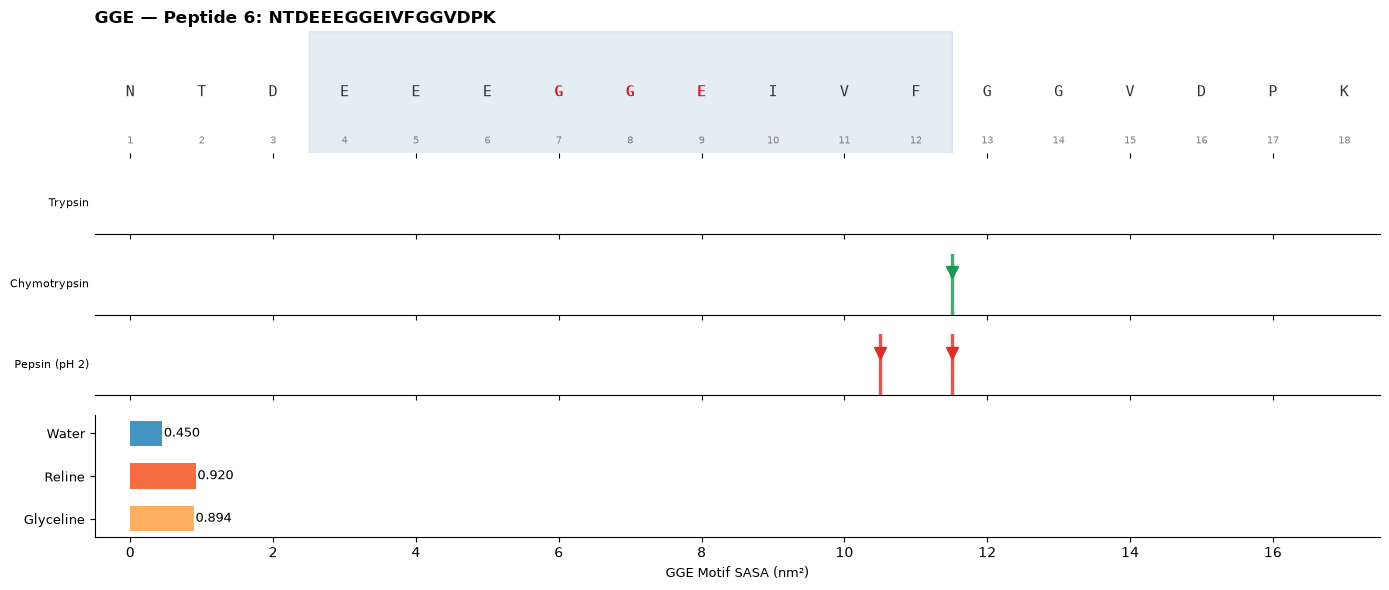

Saved: downstream/proteolysis/figures/cleavage_map_CME.png


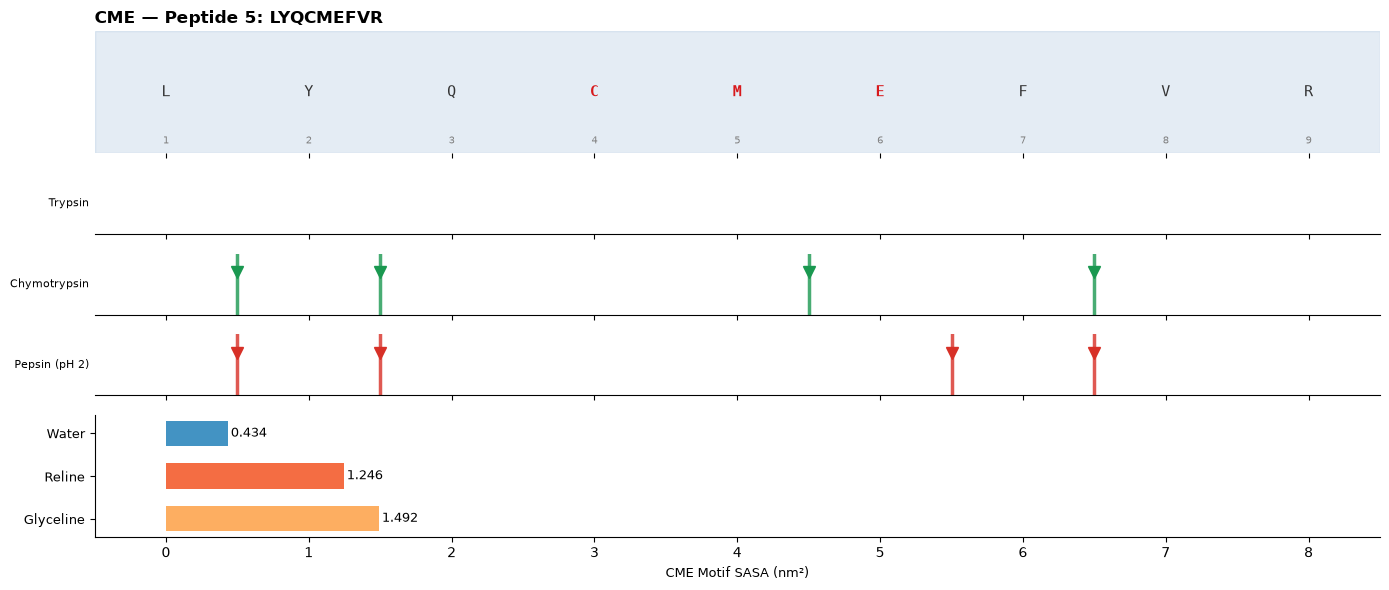

Saved: downstream/proteolysis/figures/cleavage_map_YIY.png


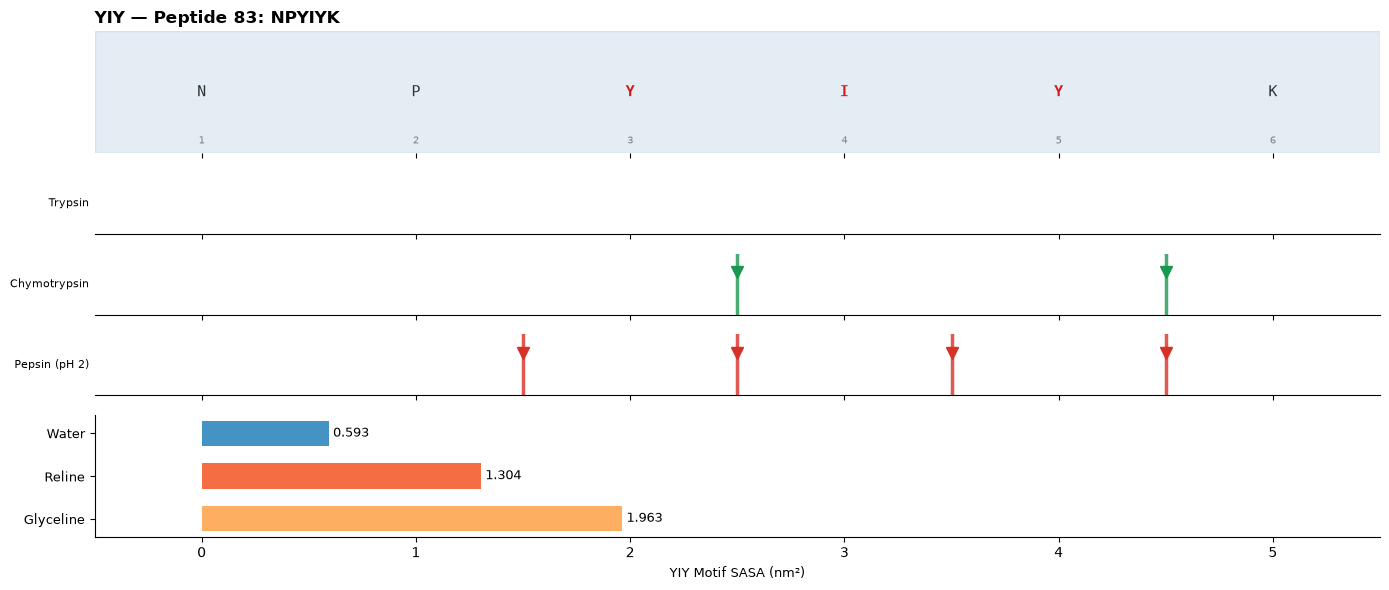

In [7]:
def plot_cleavage_map(pep_name, pep_info, df_sites_pep, figsize=(14, 6)):
    """Generate a cleavage map figure for one peptide."""
    seq = pep_info['source_seq']
    motif_pos = set(pep_info['motif_pos_source'])
    offset = pep_info['construct_offset']
    construct_len = len(pep_info['construct_seq'])
    construct_start = offset
    construct_end = offset + construct_len - 1
    
    proteases = list(PROTEASES.keys())
    n_proteases = len(proteases)
    
    fig, axes = plt.subplots(n_proteases + 2, 1, figsize=figsize,
                             gridspec_kw={'height_ratios': [2] + [1]*n_proteases + [2]},
                             sharex=True)
    
    x = np.arange(len(seq))
    
    # --- Top panel: sequence with motif and construct highlighting ---
    ax = axes[0]
    ax.set_xlim(-0.5, len(seq) - 0.5)
    ax.set_ylim(0, 1)
    
    # Construct region background
    ax.axvspan(construct_start - 0.5, construct_end + 0.5,
               alpha=0.12, color='#2166ac', label='MD construct')
    
    for i, aa in enumerate(seq):
        color = '#d7191c' if i in motif_pos else '#333333'
        weight = 'bold' if i in motif_pos else 'normal'
        ax.text(i, 0.5, aa, ha='center', va='center', fontsize=11,
                fontweight=weight, color=color,
                fontfamily='monospace')
        # Position number below
        ax.text(i, 0.1, str(i+1), ha='center', va='center', fontsize=7,
                color='grey')
    
    ax.set_title(f"{pep_name} — {pep_info['source_name']}: {seq}",
                 fontsize=12, fontweight='bold', loc='left')
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # --- Middle panels: cleavage sites per protease ---
    protease_colors = {
        'Trypsin': '#2166ac',
        'Chymotrypsin': '#1a9850',
        'Pepsin (pH 2)': '#d73027',
    }
    
    for idx, protease_name in enumerate(proteases):
        ax = axes[idx + 1]
        sites = df_sites_pep[df_sites_pep['protease'] == protease_name]
        color = protease_colors.get(protease_name, '#666666')
        
        ax.set_xlim(-0.5, len(seq) - 0.5)
        ax.set_ylim(0, 1)
        
        for _, site in sites.iterrows():
            pos = site['cleavage_after_pos']
            # Draw cleavage indicator between pos and pos+1
            ax.axvline(x=pos + 0.5, color=color, linewidth=2.5, alpha=0.8)
            
            # Mark if in construct
            if site['in_construct']:
                ax.plot(pos + 0.5, 0.7, marker='v', color=color,
                        markersize=8, zorder=5)
        
        ax.set_ylabel(protease_name, fontsize=8, rotation=0,
                      ha='right', va='center')
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
    
    # --- Bottom panel: SASA context bar ---
    ax = axes[-1]
    
    sasa_water = PHASE3_MOTIF_SASA[(pep_name, 'water')]['SASA']
    sasa_reline = PHASE3_MOTIF_SASA[(pep_name, 'reline')]['SASA']
    sasa_glyceline = PHASE3_MOTIF_SASA[(pep_name, 'glyceline')]['SASA']
    
    bar_x = [0, 1, 2]
    bar_vals = [sasa_water, sasa_reline, sasa_glyceline]
    bar_colors = ['#4393c3', '#f46d43', '#fdae61']
    bar_labels = ['Water', 'Reline', 'Glyceline']
    
    bars = ax.barh(bar_x, bar_vals, color=bar_colors, height=0.6, edgecolor='none')
    ax.set_yticks(bar_x)
    ax.set_yticklabels(bar_labels, fontsize=9)
    ax.set_xlabel(f'{pep_info["motif"]} Motif SASA (nm²)', fontsize=9)
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for bar, val in zip(bars, bar_vals):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    
    fig.tight_layout()
    return fig


# Generate figures for all peptides
for pep_name, pep_info in PEPTIDES.items():
    df_pep = df_sites[df_sites['peptide'] == pep_name]
    fig = plot_cleavage_map(pep_name, pep_info, df_pep)
    fig_path = FIG_DIR / f'cleavage_map_{pep_name}.png'
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"Saved: {fig_path}")
    plt.show()

## 8. Summary: fragments containing intact motifs

The key question for Step 4.2 (bioactivity prediction): which protease
digestion conditions release fragments that preserve the intact bioactive motif?

In [8]:
# Filter fragments with intact motifs
df_intact = df_fragments[df_fragments['motif_status'] == 'intact'].copy()

print("="*70)
print("FRAGMENTS CONTAINING INTACT BIOACTIVE MOTIFS")
print("="*70)
print(f"\nTotal fragments across all peptides × proteases: {len(df_fragments)}")
print(f"Fragments with intact motif: {len(df_intact)}")
print(f"Fragments with partial motif: {(df_fragments['motif_status']=='partial').sum()}")
print(f"Fragments with no motif: {(df_fragments['motif_status']=='none').sum()}")

print("\n--- Intact-motif fragments (candidates for bioactivity screening) ---")
for pep_name in PEPTIDES:
    df_pep = df_intact[df_intact['peptide'] == pep_name]
    if len(df_pep) > 0:
        print(f"\n  {pep_name}:")
        for _, row in df_pep.iterrows():
            print(f"    {row['protease']:20s} → {row['fragment_sequence']} "
                  f"({row['fragment_length']} aa, pos {row['fragment_start_1idx']}–{row['fragment_end_1idx']})")
    else:
        print(f"\n  {pep_name}: No fragments with intact motif (motif disrupted by all proteases)")

FRAGMENTS CONTAINING INTACT BIOACTIVE MOTIFS

Total fragments across all peptides × proteases: 26
Fragments with intact motif: 6
Fragments with partial motif: 7
Fragments with no motif: 13

--- Intact-motif fragments (candidates for bioactivity screening) ---

  GGE:
    Trypsin              → NTDEEEGGEIVFGGVDPK (18 aa, pos 1–18)
    Chymotrypsin         → NTDEEEGGEIVF (12 aa, pos 1–12)
    Pepsin (pH 2)        → NTDEEEGGEIV (11 aa, pos 1–11)

  CME:
    Trypsin              → LYQCMEFVR (9 aa, pos 1–9)
    Pepsin (pH 2)        → QCME (4 aa, pos 3–6)

  YIY:
    Trypsin              → NPYIYK (6 aa, pos 1–6)


## 9. DES enhancement summary

Synthesise the proteolysis predictions with the Phase 3 SASA data to
produce the mechanistic argument: DES increases motif accessibility →
protease cleavage sites near/within motifs become more exposed →
predicted enhancement of bioactive peptide release.

In [9]:
print("="*70)
print("DES ENHANCEMENT PREDICTIONS — PROTEOLYSIS × SASA")
print("="*70)

for pep_name, pep_info in PEPTIDES.items():
    motif = pep_info['motif']
    seq = pep_info['source_seq']
    
    print(f"\n{'─'*60}")
    print(f"{pep_name} ({pep_info['source_name']}): {seq}")
    print(f"{'─'*60}")
    
    # SASA context
    sasa_w = PHASE3_MOTIF_SASA[(pep_name, 'water')]['SASA']
    for des in ['reline', 'glyceline']:
        delta = PHASE3_DELTAS[(pep_name, des)]
        sasa_d = PHASE3_MOTIF_SASA[(pep_name, des)]['SASA']
        print(f"  {motif} SASA: {sasa_w:.3f} (water) → {sasa_d:.3f} ({des}) "
              f"| Δ = +{delta['dSASA']:.3f} nm² (+{delta['dSASA_pct']:.0f}%) "
              f"| ES = {delta['ES']:.1f}")
    
    # Cleavage sites in construct
    df_pep_sites = df_overlay[
        (df_overlay['peptide'] == pep_name) & 
        (df_overlay['in_construct'] == True)
    ]
    
    if len(df_pep_sites) > 0:
        print(f"\n  Cleavage sites within MD construct ({len(df_pep_sites)}):")
        for _, site in df_pep_sites.iterrows():
            adj = ' [adjacent to motif]' if site['adjacent_to_motif'] else ''
            wm = ' [WITHIN MOTIF]' if site['within_motif'] else ''
            print(f"    pos {site['cleavage_after_pos_1idx']}: "
                  f"{site['P1_residue']}|{site['P1_prime_residue']} "
                  f"({site['protease']}){adj}{wm}")
        print(f"\n  → Prediction: DES enhances cleavage at these sites due to")
        print(f"    increased motif SASA (+{PHASE3_DELTAS[(pep_name, 'reline')]['dSASA_pct']:.0f}% "
              f"reline, +{PHASE3_DELTAS[(pep_name, 'glyceline')]['dSASA_pct']:.0f}% glyceline)")
    else:
        print(f"\n  No cleavage sites within MD construct.")
    
    # Sites outside construct
    df_outside = df_overlay[
        (df_overlay['peptide'] == pep_name) & 
        (df_overlay['in_construct'] == False)
    ]
    if len(df_outside) > 0:
        print(f"\n  Cleavage sites outside construct ({len(df_outside)}): "
              f"no MD accessibility data available")

# --- Key fragments for Step 4.2 ---
print(f"\n\n{'='*70}")
print("FRAGMENTS FOR BIOACTIVITY SCREENING (Step 4.2 input)")
print(f"{'='*70}")

# Collect unique fragments with intact motifs
bioactive_candidates = df_intact[['peptide', 'motif', 'protease', 
                                   'fragment_sequence', 'fragment_length'
                                  ]].drop_duplicates(subset=['fragment_sequence'])

# Also include the original motif tripeptides themselves
motif_tripeptides = []
for pep_name, pep_info in PEPTIDES.items():
    motif_tripeptides.append({
        'peptide': pep_name,
        'motif': pep_info['motif'],
        'protease': 'Motif only (reference)',
        'fragment_sequence': pep_info['motif'],
        'fragment_length': 3,
    })
df_motif_ref = pd.DataFrame(motif_tripeptides)

bioactive_candidates = pd.concat([bioactive_candidates, df_motif_ref], 
                                  ignore_index=True).drop_duplicates(
                                      subset=['fragment_sequence'])

print(f"\n{len(bioactive_candidates)} unique candidate sequences for bioactivity prediction:")
for _, row in bioactive_candidates.iterrows():
    print(f"  {row['fragment_sequence']:25s} ({row['fragment_length']} aa) "
          f"from {row['peptide']} via {row['protease']}")

# Export candidate list
bioactive_candidates.to_csv(OUT_DIR / 'bioactivity_candidates.csv', index=False)
print(f"\nSaved → {OUT_DIR / 'bioactivity_candidates.csv'}")

DES ENHANCEMENT PREDICTIONS — PROTEOLYSIS × SASA

────────────────────────────────────────────────────────────
GGE (Peptide 6): NTDEEEGGEIVFGGVDPK
────────────────────────────────────────────────────────────
  GGE SASA: 0.450 (water) → 0.920 (reline) | Δ = +0.470 nm² (+104%) | ES = 36.9
  GGE SASA: 0.450 (water) → 0.894 (glyceline) | Δ = +0.444 nm² (+99%) | ES = 30.6

  Cleavage sites within MD construct (3):
    pos 12: F|G (Chymotrypsin)
    pos 11: V|F (Pepsin (pH 2))
    pos 12: F|G (Pepsin (pH 2))

  → Prediction: DES enhances cleavage at these sites due to
    increased motif SASA (+104% reline, +99% glyceline)

────────────────────────────────────────────────────────────
CME (Peptide 5): LYQCMEFVR
────────────────────────────────────────────────────────────
  CME SASA: 0.434 (water) → 1.246 (reline) | Δ = +0.812 nm² (+187%) | ES = 50.4
  CME SASA: 0.434 (water) → 1.492 (glyceline) | Δ = +1.058 nm² (+244%) | ES = 54.1

  Cleavage sites within MD construct (8):
    pos 1: L|Y (Chy

## 10. Combined cleavage × SASA figure

Summary figure showing SASA enhancement bars alongside cleavage site counts
for each peptide — the visual centrepiece of the proteolysis analysis.

Saved: downstream/proteolysis/figures/proteolysis_sasa_summary.png


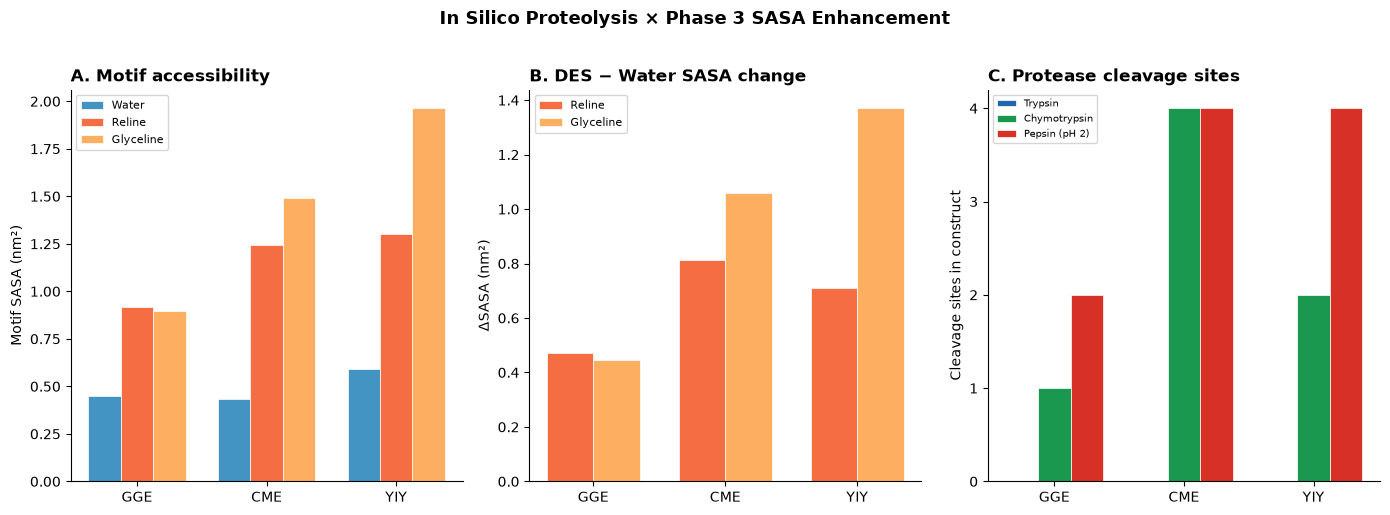

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

pep_names = list(PEPTIDES.keys())
solvent_colors = {'water': '#4393c3', 'reline': '#f46d43', 'glyceline': '#fdae61'}

# Panel A: Motif SASA by solvent
ax = axes[0]
x_pos = np.arange(len(pep_names))
width = 0.25
for j, solvent in enumerate(SOLVENTS):
    vals = [PHASE3_MOTIF_SASA[(p, solvent)]['SASA'] for p in pep_names]
    ax.bar(x_pos + j * width, vals, width, label=solvent.capitalize(),
           color=solvent_colors[solvent], edgecolor='white', linewidth=0.5)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(pep_names)
ax.set_ylabel('Motif SASA (nm²)')
ax.set_title('A. Motif accessibility', fontweight='bold', loc='left')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel B: ΔSASA (DES − water)
ax = axes[1]
des_solvents = ['reline', 'glyceline']
des_colors = ['#f46d43', '#fdae61']
width = 0.35
for j, (des, color) in enumerate(zip(des_solvents, des_colors)):
    vals = [PHASE3_DELTAS[(p, des)]['dSASA'] for p in pep_names]
    ax.bar(x_pos + j * width, vals, width, label=des.capitalize(),
           color=color, edgecolor='white', linewidth=0.5)
ax.set_xticks(x_pos + width / 2)
ax.set_xticklabels(pep_names)
ax.set_ylabel('ΔSASA (nm²)')
ax.set_title('B. DES − Water SASA change', fontweight='bold', loc='left')
ax.legend(fontsize=8)
ax.axhline(0, color='grey', linewidth=0.5, linestyle='-')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel C: Cleavage sites in construct per protease
ax = axes[2]
protease_colors_list = ['#2166ac', '#1a9850', '#d73027']
protease_names = list(PROTEASES.keys())
width = 0.25
for j, (protease, color) in enumerate(zip(protease_names, protease_colors_list)):
    counts = []
    for pep in pep_names:
        n = len(df_sites[(df_sites['peptide'] == pep) & 
                         (df_sites['protease'] == protease) &
                         (df_sites['in_construct'] == True)])
        counts.append(n)
    ax.bar(x_pos + j * width, counts, width, label=protease,
           color=color, edgecolor='white', linewidth=0.5)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(pep_names)
ax.set_ylabel('Cleavage sites in construct')
ax.set_title('C. Protease cleavage sites', fontweight='bold', loc='left')
ax.legend(fontsize=7)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('In Silico Proteolysis × Phase 3 SASA Enhancement',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
fig_path = FIG_DIR / 'proteolysis_sasa_summary.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved: {fig_path}")
plt.show()

Saved: cleavage_map_GGE.png


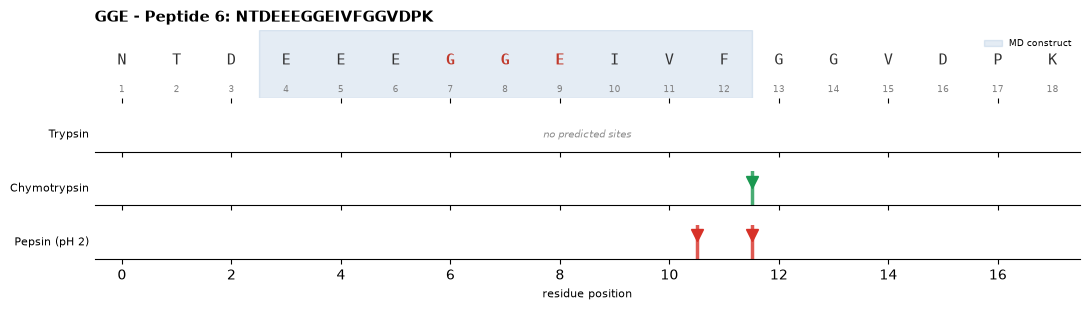

Saved: cleavage_map_CME.png


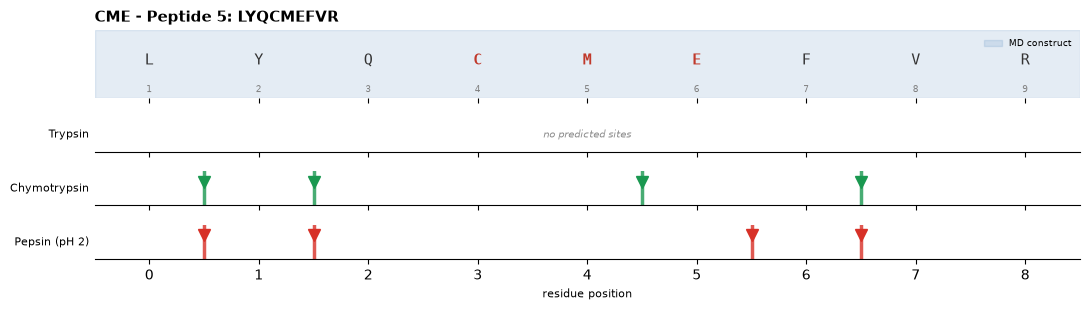

Saved: cleavage_map_YIY.png


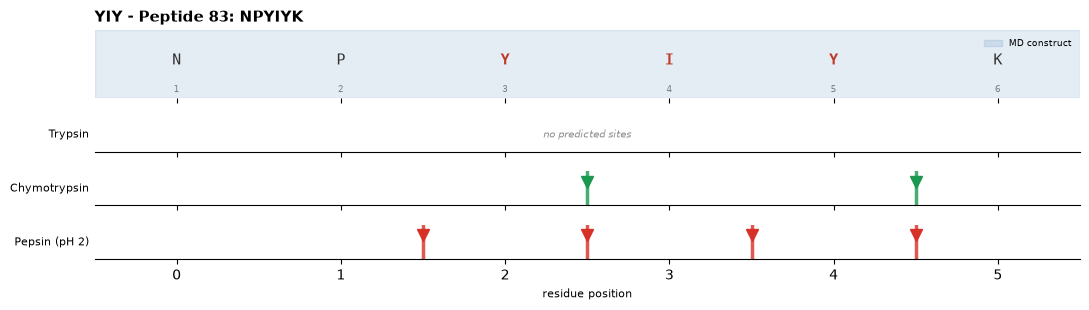

In [11]:
# =============================================================================
# Cell 14 (REPLACEMENT) — cleavage map: sequence + protease cut sites ONLY
# The SASA bottom panel is removed: absolute per-solvent motif SASA duplicated
# the §3.1 convergence triptych, and motif opening is already made in §3.2.
# This figure's job is the one thing no other figure shows — WHERE each protease
# cuts on the chain, relative to the motif and the MD construct region.
# Cleavage-arrow COMPUTATION and protease colours are unchanged from the original.
# =============================================================================

def plot_cleavage_map(pep_name, pep_info, df_sites_pep, figsize=(11, 3.2)):
    seq = pep_info['source_seq']
    motif_pos = set(pep_info['motif_pos_source'])
    offset = pep_info['construct_offset']
    construct_len = len(pep_info['construct_seq'])
    construct_start, construct_end = offset, offset + construct_len - 1
    proteases = list(PROTEASES.keys())
    n_proteases = len(proteases)

    # sequence track + one lane per protease (no SASA panel)
    fig, axes = plt.subplots(n_proteases + 1, 1, figsize=figsize,
                             gridspec_kw={'height_ratios': [2] + [1]*n_proteases},
                             sharex=True)

    # --- Top: sequence with motif + construct highlight ---
    ax = axes[0]
    ax.set_xlim(-0.5, len(seq) - 0.5); ax.set_ylim(0, 1)
    ax.axvspan(construct_start - 0.5, construct_end + 0.5, alpha=0.12, color='#2166ac',
               label='MD construct')
    for i, aa in enumerate(seq):
        col = '#c0392b' if i in motif_pos else '#333333'
        wt = 'bold' if i in motif_pos else 'normal'
        ax.text(i, 0.55, aa, ha='center', va='center', fontsize=11, fontweight=wt,
                color=col, fontfamily='monospace')
        ax.text(i, 0.12, str(i+1), ha='center', va='center', fontsize=6.5, color='grey')
    ax.set_title(f"{pep_name} - {pep_info['source_name']}: {seq}", fontsize=11,
                 fontweight='bold', loc='left')
    ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

    # --- Protease lanes: vertical line at each cut, filled marker if in construct ---
    protease_colors = {'Trypsin': '#2166ac', 'Chymotrypsin': '#1a9850', 'Pepsin (pH 2)': '#d73027'}
    for idx, pr in enumerate(proteases):
        ax = axes[idx + 1]
        sites = df_sites_pep[df_sites_pep['protease'] == pr]
        color = protease_colors.get(pr, '#666666')
        ax.set_xlim(-0.5, len(seq) - 0.5); ax.set_ylim(0, 1)
        n_in = 0
        for _, site in sites.iterrows():
            pos = site['cleavage_after_pos']
            ax.axvline(x=pos + 0.5, color=color, lw=2.5, alpha=0.8)
            if site['in_construct']:
                ax.plot(pos + 0.5, 0.7, marker='v', color=color, markersize=8, zorder=5)
                n_in += 1
        # zero-count lane gets an explicit "no sites" note (distinct from missing data)
        if len(sites) == 0:
            ax.text(len(seq)/2 - 0.5, 0.5, 'no predicted sites', ha='center', va='center',
                    fontsize=7, style='italic', color='0.55')
        ax.set_ylabel(pr, fontsize=8, rotation=0, ha='right', va='center')
        ax.set_yticks([])
        for sp in ('top','right','left'): ax.spines[sp].set_visible(False)

    axes[-1].set_xlabel('residue position', fontsize=8)
    axes[0].legend(fontsize=6.5, frameon=False, loc='upper right')
    fig.tight_layout()
    return fig

for pep_name, pep_info in PEPTIDES.items():
    df_pep = df_sites[df_sites['peptide'] == pep_name]
    fig = plot_cleavage_map(pep_name, pep_info, df_pep)
    fig.savefig(FIG_DIR / f'cleavage_map_{pep_name}.png', dpi=300, bbox_inches='tight')
    print(f"Saved: cleavage_map_{pep_name}.png")
    plt.show()

## 11. Observations

### What this analysis shows

1. **Trypsin produces no internal cleavage** on any of the three source peptides.
   This is expected: the Durrani et al. peptides were identified by LC-MS/MS
   after tryptic digestion, so they are themselves tryptic fragments — their
   terminal K/R residues are the sites at which trypsin *generated* them from
   the parent protein. This confirms internal sequence consistency.

2. **Chymotrypsin cleaves within the CME and YIY motifs** but preserves GGE
   intact (cleaving downstream at F12). The M residue in CME and Y residues in
   YIY are canonical chymotryptic P1 residues. This means chymotryptic digestion
   would disrupt the CME and YIY motifs — a prediction that could be tested
   experimentally.

3. **Pepsin preserves the CME motif** in a 4-residue fragment (QCME) but
   completely fragments YIY into single amino acids. GGE is preserved in an
   11-residue fragment.

4. **SASA overlay** — All three motifs show large, statistically unambiguous SASA
   increases in both DES solvents (ES > 30 for all comparisons). Cleavage sites
   within or adjacent to the motif regions are predicted to be more accessible
   to protease active sites in DES than in water.

5. **Mechanistic link** — The combination of increased motif SASA and decreased
   water coordination in DES suggests a solvent restructuring mechanism: DES
   components (particularly urea in reline) displace ordered water from the
   peptide surface, increasing backbone exposure. This would facilitate
   protease access to scissile bonds near the motifs, consistent with the
   enhanced bioactive peptide yield observed by Durrani et al.

### Interpretive note on trypsin

The absence of internal tryptic sites means the DES enhancement mechanism
for these peptides does not operate through differential trypsin cleavage
of the released peptides themselves. Rather, the DES effect likely operates
upstream — on the intact parent protein — where increased surface exposure
of K/R-containing regions in DES would enhance tryptic release of these
peptide fragments in the first place. This is consistent with the Durrani
et al. finding that DES extraction yielded 600 total peptides vs fewer
under conventional conditions.

### Limitations

- Protease specificity rules are deterministic approximations; real cleavage
  efficiency depends on kinetics, enzyme concentration, and local structure
- Only motif-level SASA is used (not per-residue at each cleavage site)
  unless the Phase 3 per-residue CSV is available
- The Durrani source peptides are short; some protease digestions produce
  di- or tripeptides that may be below the practical detection limit
- In vivo, DES may also affect protease activity/stability — this analysis
  considers substrate accessibility only
- The analysis treats each peptide in isolation; in the intact protein,
  flanking sequence context may alter protease accessibility

### Next step

The fragment list in `bioactivity_candidates.csv` feeds directly into
Step 4.2 (Bioactivity Prediction).